# Lab 4: Hyperspectral Data & Water Quality Analysis

This notebook provides a tool for browsing a hyperspectral data cube, visualizing it in RGB, viewing the spectral signature of a selected pixel, and exporting it to a CSV file.

In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Ensure the backend supports interactive plots in Jupyter
# Requires ipympl installed (`pip install ipympl`) 

In [11]:
# 1. Provide the path to your hyperspectral data cube (e.g., GeoTIFF)
data_path = 'path_to_your_hyperspectral_data.tif'

# Attempt to load the dataset, or generate synthetic data if not found
try:
    with rasterio.open(data_path) as src:
        cube = src.read()
        # The expected shape is (bands, height, width)
        bands, height, width = cube.shape
        
    print(f"Successfully loaded {data_path}. Shape: {cube.shape}")
except Exception as e:
    print(f"Warning: Could not load {data_path}.")
    print("Generating a synthetic hyperspectral data cube for demonstration purposes.")
    bands, height, width = 100, 50, 50
    cube = np.random.rand(bands, height, width)


Generating a synthetic hyperspectral data cube for demonstration purposes.


In [12]:
# 2. Define RGB bands for visualization (adjust indices based on your sensor and dataset)
r_band, g_band, b_band = 30, 20, 10
r_band = min(r_band, bands - 1)
g_band = min(g_band, bands - 1)
b_band = min(b_band, bands - 1)

# Normalize the RGB image for visualization
rgb_image = np.stack([cube[r_band], cube[g_band], cube[b_band]], axis=-1)
# Min-Max scaling for display
rgb_image = (rgb_image - np.min(rgb_image)) / (np.max(rgb_image) - np.min(rgb_image) + 1e-8)


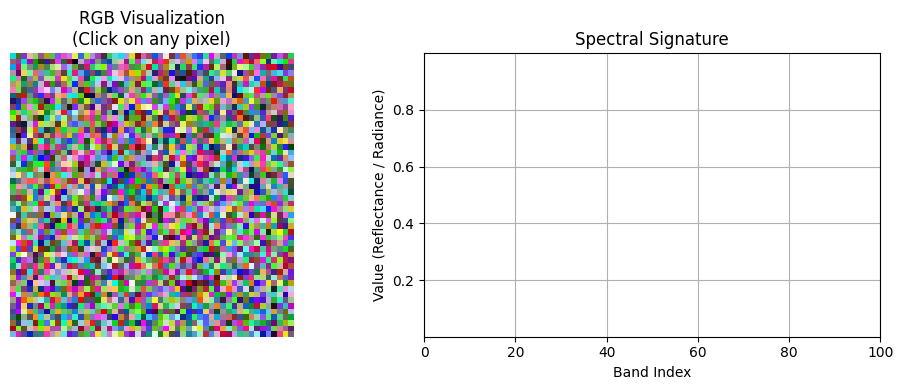

In [13]:
# 3. Create interactive figure with RGB view and Spectral Profile view
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(rgb_image)
ax1.set_title("RGB Visualization\n(Click on any pixel)")
ax1.axis('off')

# Setup empty plot for the spectral signature
line, = ax2.plot([], [], lw=2, color='blue')
ax2.set_xlim(0, bands)
ax2.set_ylim(np.min(cube), np.max(cube))
ax2.set_title("Spectral Signature")
ax2.set_xlabel("Band Index")
ax2.set_ylabel("Value (Reflectance / Radiance)")
ax2.grid(True)

# Dictionary to store the currently selected spectral signature for exporting later
selected_signature = {'pixel_x': None, 'pixel_y': None, 'signature': None}

def on_click(event):
    # Check if the click is within the image axes (ax1)
    if event.inaxes == ax1:
        x, y = int(event.xdata), int(event.ydata)
        
        # Validate click bounds (just in case)
        if 0 <= x < width and 0 <= y < height:
            # Extract the signature across all bands at (y, x)
            signature = cube[:, y, x]
            
            # Update the plotted line
            line.set_data(range(bands), signature)
            
            # Dynamically adjust y-axis limits to fit the new signature clearly
            min_val, max_val = np.min(signature), np.max(signature)
            ax2.set_ylim(min_val - 0.1 * abs(min_val), max_val + 0.1 * abs(max_val))
            ax2.set_title(f"Spectral Signature at ({x}, {y})")
            
            # Redraw the figure canvas
            fig.canvas.draw()
            
            # Store the data required for export
            selected_signature['pixel_x'] = x
            selected_signature['pixel_y'] = y
            selected_signature['signature'] = signature

# Connect the click event to the figure
cid = fig.canvas.mpl_connect('button_press_event', on_click)
plt.tight_layout()
plt.show()


In [14]:
# 4. Provide Export functionality feature (Saving the extracted signature to a CSV)
export_button = widgets.Button(description="Export to CSV", button_style='success', icon='download')
output_msg = widgets.Output()

def export_to_csv(b):
    with output_msg:
        output_msg.clear_output()
        # Ensure that a pixel has been clicked already
        if selected_signature['signature'] is not None:
            # Create a pandas DataFrame for the signature
            df = pd.DataFrame({
                'Band': range(bands),
                'Value': selected_signature['signature']
            })
            # Name the CSV with coordinates
            filename = f"spectral_signature_x{selected_signature['pixel_x']}_y{selected_signature['pixel_y']}.csv"
            
            # Save to CSV
            df.to_csv(filename, index=False)
            print(f"Successfully exported signature to {filename}")
        else:
            print("Please click on a pixel on the RGB image first before exporting.")

export_button.on_click(export_to_csv)
display(export_button, output_msg)


Button(button_style='success', description='Export to CSV', icon='download', style=ButtonStyle())

Output()